# Stage 5: Downstream Classification (yes/no/maybe)

This notebook evaluates how tokenization affects a downstream PubMedQA classifier.

Setup:
- Fixed classifier architecture: Logistic Regression on TF-IDF features.
- Only tokenization changes across configurations.
- Data split: 70/15/15 (train/val/test) from PubMedQA labeled subset.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from tokenizers import Tokenizer
from transformers import BertTokenizer, GPT2Tokenizer

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
RANDOM_SEED = 42
MAX_FEATURES = 20000
NGRAM_RANGE = (1, 2)

TOKENIZERS_DIR = "../tokenizers"

LABEL_MAP = {"no": 0, "maybe": 1, "yes": 2}
LABEL_NAMES = ["no", "maybe", "yes"]

CONFIGS = {
    "bert_base": {"type": "hf_bert", "name": "bert-base-uncased"},
    "biobert": {"type": "hf_bert", "name": "dmis-lab/biobert-base-cased-v1.1"},
    "gpt2": {"type": "hf_gpt2", "name": "gpt2"},
    "biomedical_bpe_30k": {
        "type": "custom_bpe",
        "path": os.path.join(TOKENIZERS_DIR, "biomedical_bpe_30k.json"),
    },
    "biomedical_bpe_50k": {
        "type": "custom_bpe",
        "path": os.path.join(TOKENIZERS_DIR, "biomedical_bpe_50k.json"),
    },
    "biomedical_bpe_100k": {
        "type": "custom_bpe",
        "path": os.path.join(TOKENIZERS_DIR, "biomedical_bpe_100k.json"),
    },
}

In [3]:
def get_context_text(context_field):
    if isinstance(context_field, dict):
        contexts = context_field.get("contexts", [])
        if isinstance(contexts, list):
            return " ".join(str(part) for part in contexts)
    if isinstance(context_field, list):
        return " ".join(str(part) for part in context_field)
    return str(context_field)


def load_labeled_dataframe():
    ds = load_dataset("qiaojin/PubMedQA", "pqa_labeled")["train"]
    df = pd.DataFrame(
        {
            "question": ds["question"],
            "context_text": [get_context_text(x) for x in ds["context"]],
            "label_text": ds["final_decision"],
        }
    )
    df["text"] = df["question"].fillna("") + " [SEP] " + df["context_text"].fillna("")
    df["label"] = df["label_text"].map(LABEL_MAP)
    return df[["text", "label", "label_text"]]


def split_data(df):
    X = df["text"].tolist()
    y = df["label"].tolist()

    X_train, X_temp, y_train, y_temp = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=RANDOM_SEED,
        stratify=y,
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        random_state=RANDOM_SEED,
        stratify=y_temp,
    )

    return (X_train, y_train), (X_val, y_val), (X_test, y_test)


def build_tokenize_fn(config):
    if config["type"] == "hf_bert":
        tok = BertTokenizer.from_pretrained(config["name"])

        def tokenize(text):
            return tok.tokenize(text)

        return tokenize

    if config["type"] == "hf_gpt2":
        tok = GPT2Tokenizer.from_pretrained(config["name"])

        def tokenize(text):
            return tok.tokenize(text)

        return tokenize

    if config["type"] == "custom_bpe":
        tok = Tokenizer.from_file(config["path"])

        def tokenize(text):
            return tok.encode(text).tokens

        return tokenize

    raise ValueError(f"Unsupported config type: {config['type']}")


def evaluate_configuration(name, config, X_train, y_train, X_val, y_val, X_test, y_test):
    tokenize = build_tokenize_fn(config)
    vectorizer = TfidfVectorizer(
        tokenizer=tokenize,
        token_pattern=None,
        lowercase=False,
        max_features=MAX_FEATURES,
        ngram_range=NGRAM_RANGE,
    )

    X_train_vec = vectorizer.fit_transform(X_train)
    X_val_vec = vectorizer.transform(X_val)
    X_test_vec = vectorizer.transform(X_test)

    clf = LogisticRegression(
        max_iter=300,
        random_state=RANDOM_SEED,
        class_weight="balanced",
        n_jobs=-1,
    )
    clf.fit(X_train_vec, y_train)

    val_pred = clf.predict(X_val_vec)
    test_pred = clf.predict(X_test_vec)

    val_acc = accuracy_score(y_val, val_pred)
    test_acc = accuracy_score(y_test, test_pred)
    val_f1 = f1_score(y_val, val_pred, average="macro")
    test_f1 = f1_score(y_test, test_pred, average="macro")
    cm = confusion_matrix(y_test, test_pred, labels=[0, 1, 2])

    return {
        "config_name": name,
        "val_accuracy": float(val_acc),
        "test_accuracy": float(test_acc),
        "val_f1_macro": float(val_f1),
        "test_f1_macro": float(test_f1),
        "n_features": int(X_train_vec.shape[1]),
        "confusion_matrix": cm,
    }


def plot_confusion_matrix(cm, config_name):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"Confusion Matrix ({config_name})")
    plt.colorbar()
    ticks = np.arange(len(LABEL_NAMES))
    plt.xticks(ticks, LABEL_NAMES)
    plt.yticks(ticks, LABEL_NAMES)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.show()

In [4]:
df = load_labeled_dataframe()
(X_train, y_train), (X_val, y_val), (X_test, y_test) = split_data(df)

print(f"Train size: {len(X_train)}")
print(f"Val size: {len(X_val)}")
print(f"Test size: {len(X_test)}")

Train size: 700
Val size: 150
Test size: 150


In [5]:
results = []
confusions = {}

for name, config in CONFIGS.items():
    out = evaluate_configuration(name, config, X_train, y_train, X_val, y_val, X_test, y_test)
    results.append(
        {
            "config_name": out["config_name"],
            "val_accuracy": out["val_accuracy"],
            "test_accuracy": out["test_accuracy"],
            "val_f1_macro": out["val_f1_macro"],
            "test_f1_macro": out["test_f1_macro"],
            "n_features": out["n_features"],
            "stage": "stage5_downstream_classification",
        }
    )
    confusions[name] = out["confusion_matrix"].tolist()

results_df = pd.DataFrame(results).sort_values(by="test_f1_macro", ascending=False)
results_df

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (534 > 512). Running this sequence through the model will result in indexing errors
/home/belyak_anya/Innopolis/NLP/project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/belyak_anya/Innopolis/NLP/project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/belyak_anya/Innopolis/NLP/project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', p

,config_name,val_accuracy,test_accuracy,val_f1_macro,test_f1_macro,n_features,stage
4,biomedical_bpe_50k,0.493333,0.566667,0.300231,0.371804,20000,stage5_downstream_classification
5,biomedical_bpe_100k,0.493333,0.566667,0.300231,0.371804,20000,stage5_downstream_classification
3,biomedical_bpe_30k,0.493333,0.566667,0.305294,0.371045,20000,stage5_downstream_classification
2,gpt2,0.480000,0.566667,0.294396,0.364255,20000,stage5_downstream_classification
0,bert_base,0.473333,0.560000,0.282554,0.358159,20000,stage5_downstream_classification
1,biobert,0.453333,0.553333,0.281794,0.352070,20000,stage5_downstream_classification


Stage 5 downstream results:


,config_name,val_accuracy,test_accuracy,val_f1_macro,test_f1_macro,n_features,stage
4,biomedical_bpe_50k,0.493333,0.566667,0.300231,0.371804,20000,stage5_downstream_classification
5,biomedical_bpe_100k,0.493333,0.566667,0.300231,0.371804,20000,stage5_downstream_classification
3,biomedical_bpe_30k,0.493333,0.566667,0.305294,0.371045,20000,stage5_downstream_classification
2,gpt2,0.480000,0.566667,0.294396,0.364255,20000,stage5_downstream_classification
0,bert_base,0.473333,0.560000,0.282554,0.358159,20000,stage5_downstream_classification
1,biobert,0.453333,0.553333,0.281794,0.352070,20000,stage5_downstream_classification



Confusion matrices:

biomedical_bpe_50k


,no,maybe,yes
no,20,1,30
maybe,3,0,13
yes,18,0,65


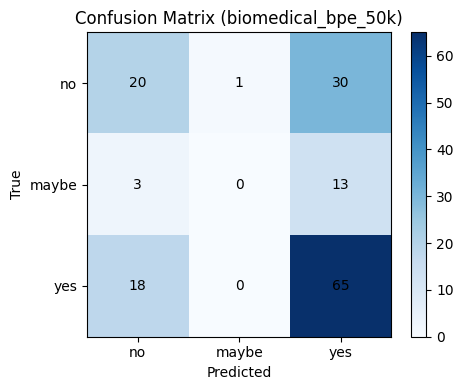


biomedical_bpe_100k


,no,maybe,yes
no,20,1,30
maybe,3,0,13
yes,18,0,65


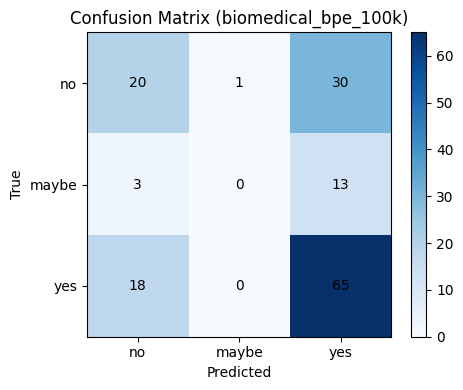


biomedical_bpe_30k


,no,maybe,yes
no,20,0,31
maybe,2,0,14
yes,18,0,65


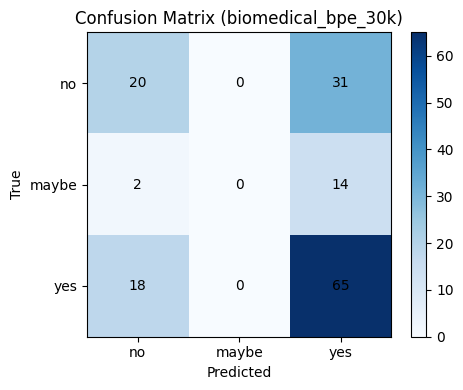


gpt2


,no,maybe,yes
no,18,0,33
maybe,3,0,13
yes,16,0,67


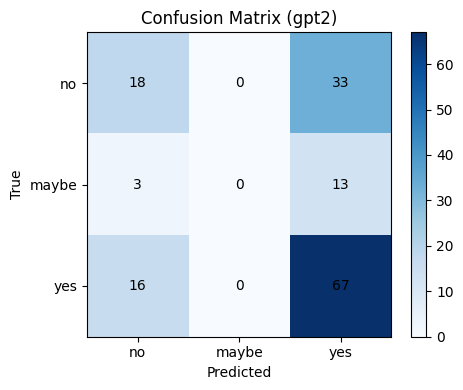


bert_base


,no,maybe,yes
no,17,0,34
maybe,4,0,12
yes,15,1,67


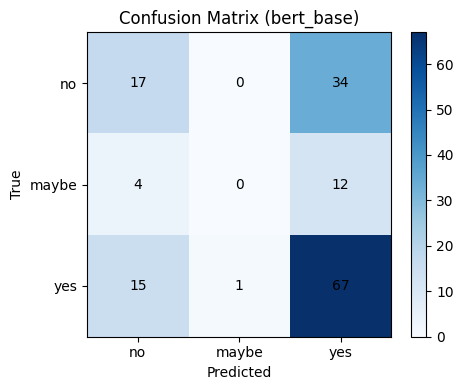


biobert


,no,maybe,yes
no,15,2,34
maybe,4,0,12
yes,12,3,68


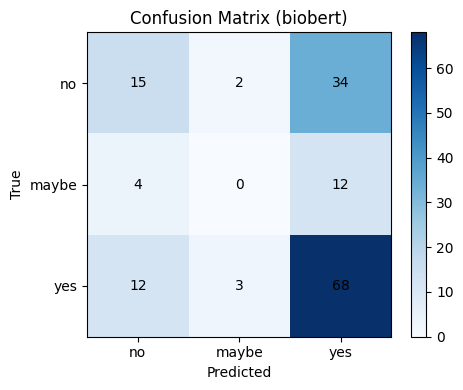

In [6]:
print("Stage 5 downstream results:")
display(results_df)

print("\nConfusion matrices:")
for config_name in results_df["config_name"].tolist():
    print(f"\n{config_name}")
    cm = np.array(confusions[config_name])
    display(pd.DataFrame(cm, index=LABEL_NAMES, columns=LABEL_NAMES))
    plot_confusion_matrix(cm, config_name)